In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Setting the background to white for all our charts
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

print("Libraries imported and white background set!")

Libraries imported and white background set!


In [3]:
df = pd.read_csv(r"D:\Corvit\Assignments\Animal Project\animal_species_200_rows.csv")

# Numbers we need: Speed, Weight, and Lifespan
data = df[['Speed', 'Weight', 'Lifespan']].dropna()

print("Dataset loaded successfully. Here is a preview:")
display(data.head())

Dataset loaded successfully. Here is a preview:


,Speed,Weight,Lifespan
0,8,349,93
1,32,381,2
2,93,201,32
3,85,21,65
4,40,80,11


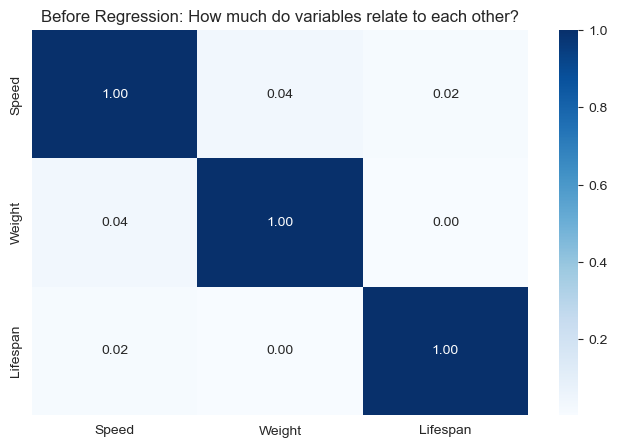

In [4]:
# 1. Correlation Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(data.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title("Before Regression: How much do variables relate to each other?")
plt.show()

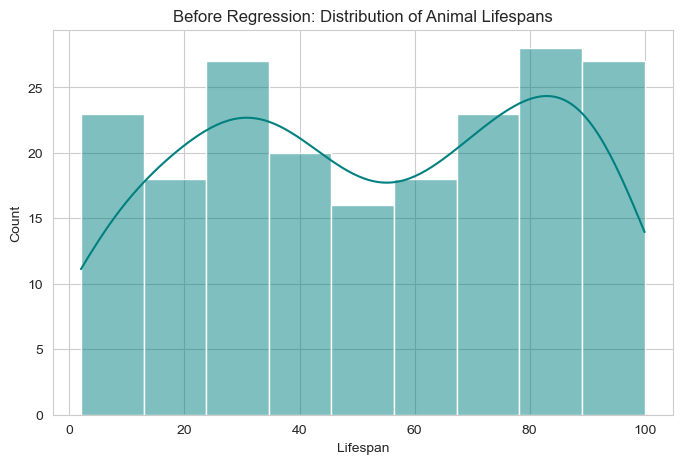

In [5]:
# 2. Distribution Plot
plt.figure(figsize=(8, 5))
sns.histplot(data['Lifespan'], kde=True, color='teal')
plt.title("Before Regression: Distribution of Animal Lifespans")
plt.show()

In [6]:
# X = Input features (Speed and Weight)
# y = Target we want to guess (Lifespan)
X = data[['Speed', 'Weight']]
y = data['Lifespan']

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data split into {len(X_train)} training rows and {len(X_test)} testing rows.")

Data split into 160 training rows and 40 testing rows.


In [7]:
# Linear Regression object
lin_model = LinearRegression()

# Training the model ('Fitting' step)
lin_model.fit(X_train, y_train)

print("The model has finished learning the patterns!")
print(f"Intercept (c): {lin_model.intercept_:.2f}")
print(f"Coefficients (m1 for Speed, m2 for Weight): {lin_model.coef_}")

The model has finished learning the patterns!
Intercept (c): 55.77
Coefficients (m1 for Speed, m2 for Weight): [-0.04059099 -0.00321137]


In [8]:
# Predicting lifespans for the test set
y_pred_lin = lin_model.predict(X_test)

# Creating a comparison table to see the guesses side-by-side
output_comparison = pd.DataFrame({
    'Actual Lifespan': y_test, 
    'Model Prediction': y_pred_lin.round(2)
})

print("First 5 predictions from the model:")
display(output_comparison.head())

First 5 predictions from the model:


,Actual Lifespan,Model Prediction
95,50,52.45
15,39,54.57
30,57,50.49
158,71,51.98
128,75,53.40


In [9]:
# Calculating mathematical scores
mse = mean_squared_error(y_test, y_pred_lin)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lin)

print("--- AFTER REGRESSION: ACCURACY REPORT ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Average Error in Years (RMSE): {rmse:.2f} years")
print(f"R-Squared Score (R²): {r2:.4f}")

--- AFTER REGRESSION: ACCURACY REPORT ---
Mean Squared Error (MSE): 963.95
Average Error in Years (RMSE): 31.05 years
R-Squared Score (R²): -0.0305


In [10]:
#Creating Polynomial Features (Degree 2 adds squared values)
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

#Training the Polynomial model
poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)

#Predicting and get the score
y_pred_poly = poly_model.predict(X_poly_test)
poly_r2 = r2_score(y_test, y_pred_poly)

print(f"Polynomial R² Score: {poly_r2:.4f}")

Polynomial R² Score: -0.0883


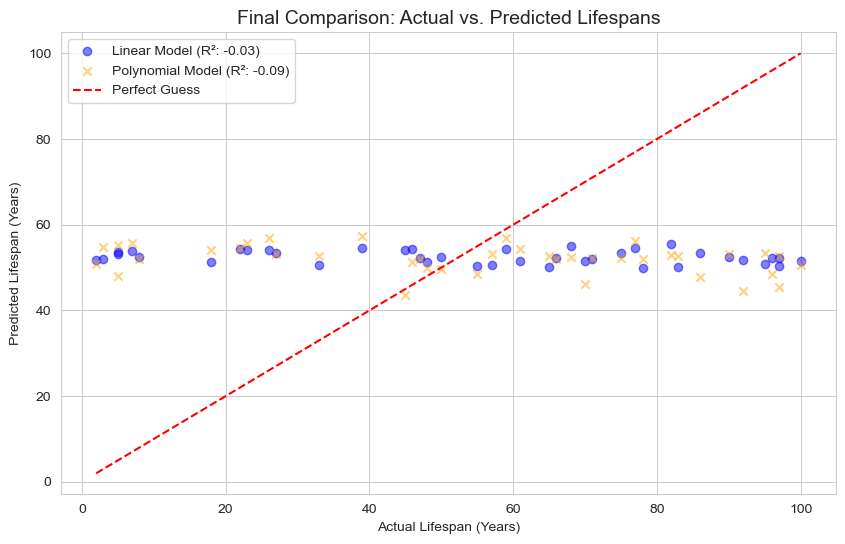

In [11]:
plt.figure(figsize=(10, 6))

# Plotting the results
plt.scatter(y_test, y_pred_lin, color='blue', alpha=0.5, label=f'Linear Model (R²: {r2:.2f})')
plt.scatter(y_test, y_pred_poly, color='orange', alpha=0.5, marker='x', label=f'Polynomial Model (R²: {poly_r2:.2f})')

# The 'Perfect Prediction' line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Guess')

plt.title("Final Comparison: Actual vs. Predicted Lifespans", fontsize=14)
plt.xlabel("Actual Lifespan (Years)")
plt.ylabel("Predicted Lifespan (Years)")
plt.legend()
plt.show()

In [14]:
import pickle

#Saving the Linear Regression Model
with open('linear_model.pkl', 'wb') as f:
    pickle.dump(lin_model, f) 

#Saving the Polynomial Regression Model 
with open('poly_model.pkl', 'wb') as f:
    pickle.dump(poly_model, f) 

#Saving the Polynomial Converter 
with open('poly_converter.pkl', 'wb') as f:
    pickle.dump(poly, f)

print("Models successfully saved!")

Models successfully saved!
